WARNING    C:\Users\GlenA\PycharmProjects\pythonProject\.venv\Lib\site-packages\cma\evolution_strategy.py:1534: UserWarning: Sampling standard deviation i=0 (and 5 others) at iteration 0 multiplied by 0.8750000000000001 to stds[0]=0.035
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"
 [py.warnings]


(20_w,40)-aCMA-ES (mu_w=11.3,w_1=16%) in dimension 13 (seed=260334, Thu Feb 26 21:16:40 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     40 1.000000000000000e+09 1.0e+00 1.82e+01  2e-02  9e+00 0:02.5
Stop reasons: {'tolfun': 1e-11}
Optimization finished.
Best fitness: 1000000000.0
Best parameters: [-3.88529648e-02 -1.24729630e-01 -4.25312763e-01 -1.69822427e-02
  2.17691139e-01  3.66005763e-01  3.27916072e+02  3.12486452e+02
  2.31304410e+01  2.67399412e+00  7.75282525e+00  1.50950779e+00
  2.44758142e+00]


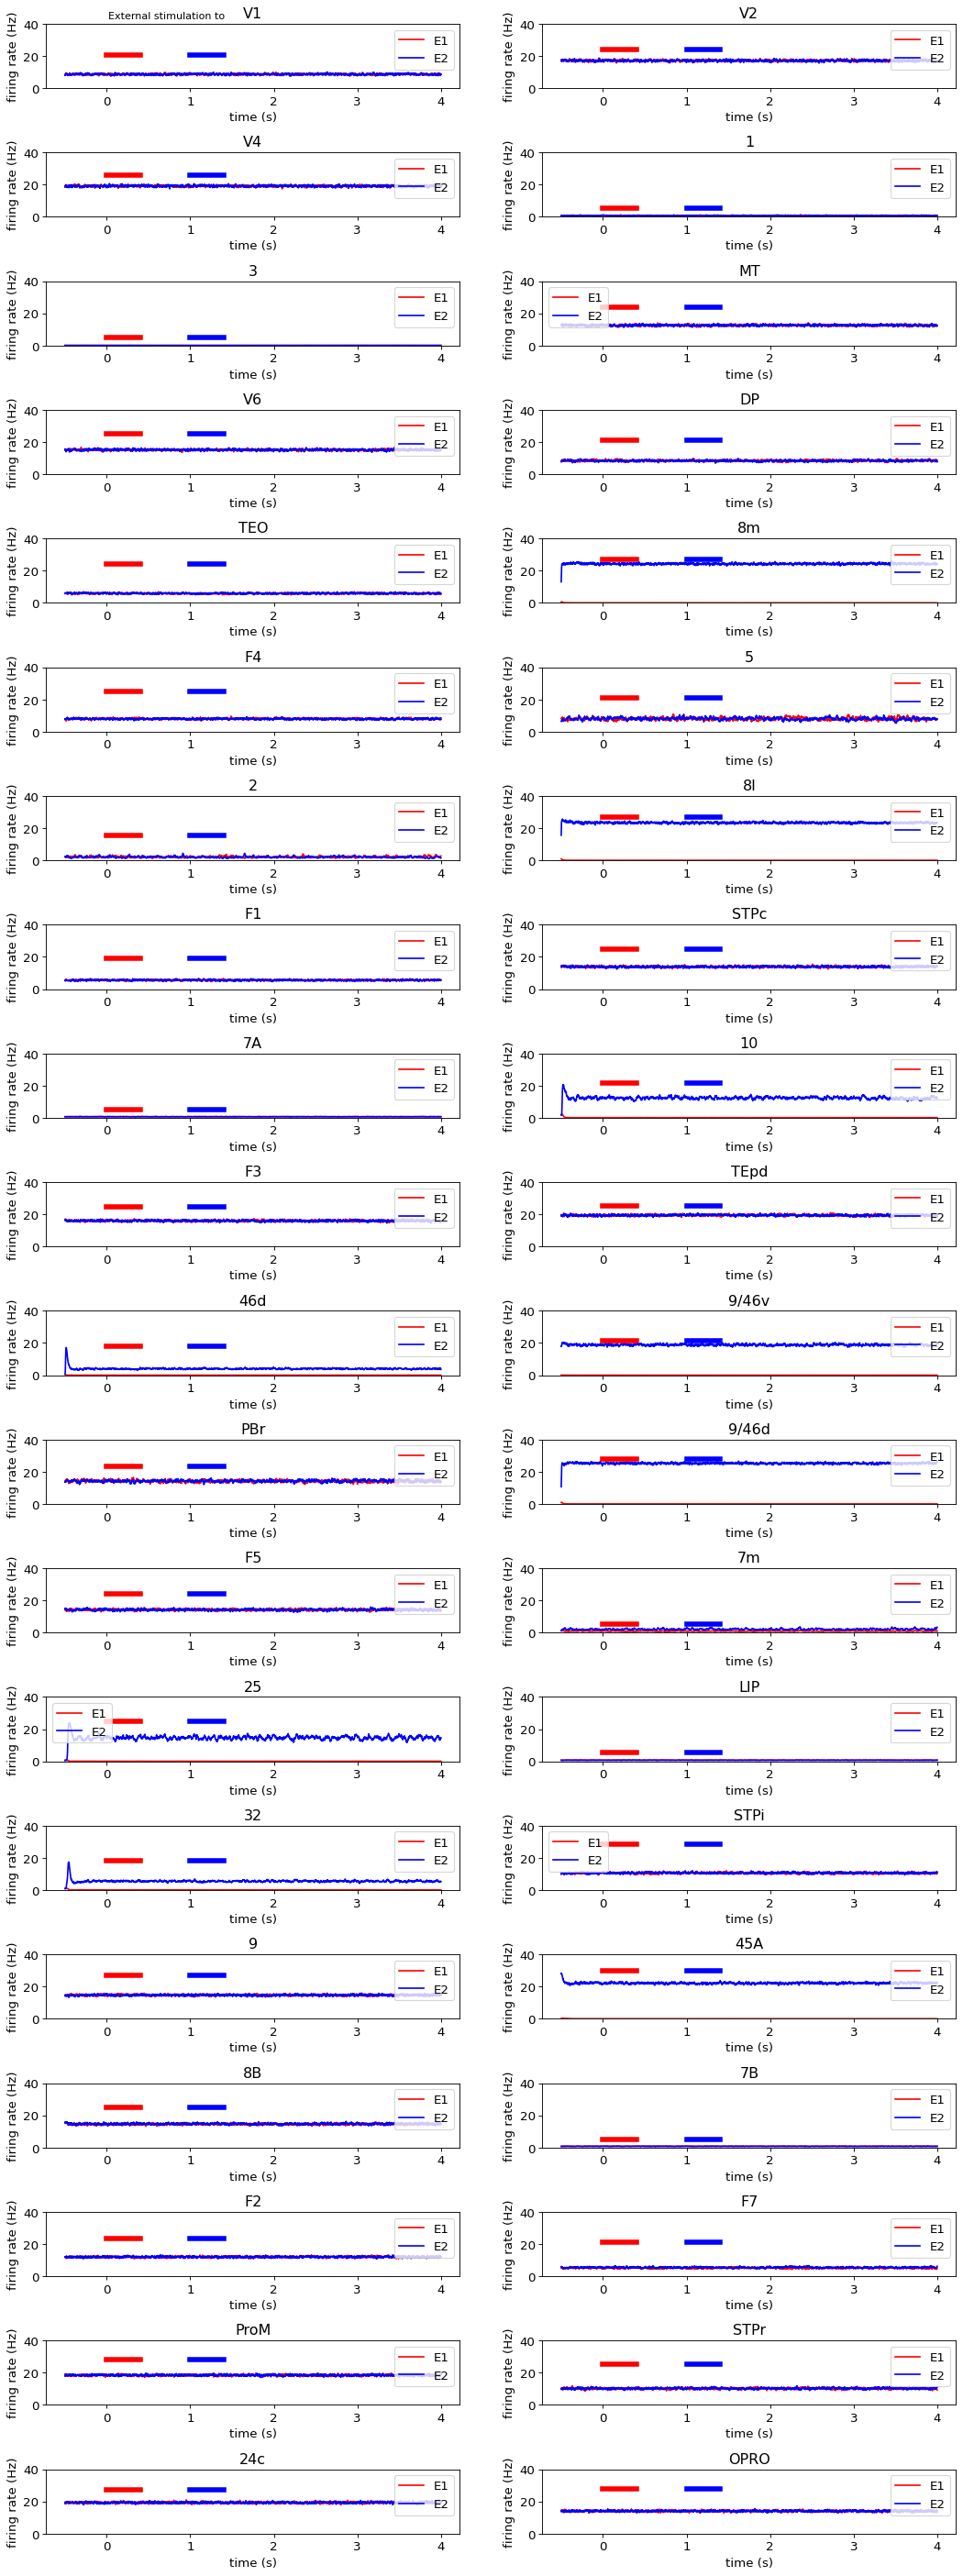

In [3]:
#let's get what we need together
from __future__ import division
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
# %matplotlib inline
import pandas
import scipy.io as sio
import brian2
import os
import copy
import pickle
import math
# import subprocess

from enum import IntEnum

# Define the function that transforms input current to changes in firing rate for excitatory neurons (Abbott and Chance, 2005)
# Update the firing rates of the interneurons using a threshold linear input/output function

def current_to_frequency(input_current, population_type, parameters):
    if population_type == 'E':
        a = parameters['a_e']
        b = parameters['b_e']
        d = parameters['d_e']
        return np.divide((a*input_current - b),(1 - np.exp(-d*(a*input_current - b))))
    if population_type == 'PV':
        c_I = parameters['c_I_pv']
        r_0 = parameters['r_0_pv']
        r = np.maximum(c_I*input_current + r_0,0)
        return r
    if population_type == 'SST':
        c_I = parameters['c_I_sst']
        r_0 = parameters['r_0_sst']
        r = np.maximum(c_I*input_current + r_0,0)
        return r
    if population_type == 'VIP':
        c_I = parameters['c_I_vip']
        r_0 = parameters['r_0_vip']
        r = np.maximum(c_I*input_current + r_0,0)
        return r

def dendrite_input_output(exc_current, inh_current, parameters):
    c1 = parameters['c1']
    c2 = parameters['c2']
    c3 = parameters['c3']
    c4 = parameters['c4']
    c5 = parameters['c5']
    c6 = parameters['c6']

    beta = c5 * np.exp(-inh_current / c6)
    return c1 * (np.tanh((exc_current + c3 * inh_current + c4) / beta)) + c2

def NMDA_deriv(S_NMDA_prev, rate_now, parameters):
    return -S_NMDA_prev / parameters['tau_nmda'] + parameters['gamma_nmda'] * (1 - S_NMDA_prev) * rate_now

def AMPA_deriv(S_AMPA_prev, rate_now, parameters):
    return -S_AMPA_prev / parameters['tau_ampa'] + parameters['gamma_ampa'] * rate_now

def GABA_deriv(S_GABA_prev,rate_now,parameters,cell_section):
    if cell_section == 'soma':
        return -S_GABA_prev/parameters['tau_gaba'] + parameters['gamma_gaba']*rate_now
    elif cell_section == 'dendrite':
        return -S_GABA_prev/parameters['tau_gaba_dend'] + parameters['gamma_gaba']*rate_now

def adaptation_deriv(S_a_prev, rate_now, parameters):
    return -S_a_prev / parameters['tau_adapt'] + rate_now

def sigmoid_DA(height, midpoint, slope):
    return np.exp(slope * (height - midpoint)) / (1 + np.exp(slope * (height - midpoint)))

PARAMS = {
    # local connectivity strengths
    # local strengths E-->
    'g_e_self': 0.18 * brian2.nA,
    'g_e_cross': 0 * brian2.nA,
    'g_pv_e': 0.174 * brian2.nA,
    'g_sst_e_self': 0.0435 * brian2.nA,
    'g_sst_e_cross': 0.0435 * brian2.nA,
    'g_vip_e': 0.058 * brian2.nA,
    # local strengths PV-->
    'g_e_pv_min': -0.001 * brian2.nA,  # dopamine dependent min PV->E strength
    'g_e_pv_max': -0.4 * brian2.nA,  # dopamine dependent max PV->E strength
    'g_pv_self': -0.18 * brian2.nA,
    # local strengths SST-->
    'g_e_sst_min': -0.09 * brian2.nA,  # dopamine dependent min SST->E strength
    'g_e_sst_max': -0.11 * brian2.nA,  # dopamine dependent max SST->E strength
    'g_pv_sst': -0.17 * brian2.nA,
    'g_vip_sst': -0.1 * brian2.nA,
    # local strengths VIP-->
    'g_sst_vip': -0.05 * brian2.nA,

    # Time constants
    'tau_nmda': 60 * brian2.ms,
    'tau_ampa': 2 * brian2.ms,
    'tau_gaba': 5 * brian2.ms,
    'tau_gaba_dend': 10 * brian2.ms,
    'tau_adapt': 0.1 * brian2.second,

    # synaptic rise constants
    'gamma_nmda': 1.282,  # unitless
    'gamma_gaba': 2,
    'gamma_ampa': 5,

    # AMPA/(AMPA+NMDA) fraction
    'ampa_frac_pv': 0.2,  # AMPA fraction (1-NMDA fraction) for PV cells
    'ampa_frac': 0.1,  # AMPA fraction (1-NMDA fraction) for all other cell types

    # Min excitatory gradient (spine count) value
    'e_grad_min': 0.45,

    # noise
    'std_noise': 5 * brian2.pA,

    # background inputs
    'I_background_e': 310 * brian2.pA,
    'I_background_i': 300 * brian2.pA,
    'I_background_dend': 30 * brian2.pA,

    # dendrite I/O function parameters
    'c1': 120 * brian2.pA,
    'c2': 136.24 * brian2.pA,
    'c3': 7.0,
    'c4': 0 * brian2.pA,
    'c5': 9.64 * brian2.pA,
    'c6': 20 * brian2.pA,

    # adaptation strengths
    'g_adapt_e': -0.004 * brian2.nA,
    'g_adapt_sst': -0.004 * brian2.nA,
    'g_adapt_vip': -0.004 * brian2.nA,

    # f-I curve parameters - Excitatory populations
    'a_e': 0.135 * brian2.Hz / brian2.pA,
    'b_e': 54 * brian2.Hz,
    'd_e': 0.308 * brian2.second,

    # f-I curve parameters - Inhibitory populations
    'c_I_sst': 132 * brian2.Hz / brian2.nA,
    'c_I_vip': 132 * brian2.Hz / brian2.nA,
    'c_I_pv': 330 * brian2.Hz / brian2.nA,
    'r_0_sst': -33 * brian2.Hz,
    'r_0_vip': -33 * brian2.Hz,
    'r_0_pv': -95 * brian2.Hz,

    # rescale FLN parameter
    'b1': 0.3,

    'debug_objective': True,

    # structural directionality parameter
    'struct_dir_logistic_gain': 4.25, # 3,#-2.3, #6 - seemed to give some transients! 5.37 I had 2.25 at some point, which produced wrong results, need to be more mindful #in the other model it worked with -3 #11

    # Long-range E targets
    'lr_e_self_dend': 0.9,
    'lr_e_cross_dend': 0.1,

    # Long-range I targets
    'lr_pv_e': 0.31,
    'lr_sst_e_self': 0.22,
    'lr_vip_e_self': 0.47,

    # Long-range I targets in FEF
    'lr_pv_e_fef': 0.2,
    'lr_sst_e_self_fef': 0.1,
    'lr_vip_e_self_fef': 0.7,

    # parameters for D1 occupancy
    'slope_d1occ': 2,
    'midpoint_d1occ': 1,

    # parameters for DA modulation of NMDA #what do they refer to?
    'slope_nmda_da': 10,
    'midpoint_nmda_da': 0.35,
    'g_nmda_da': 0.6,

    # parameters for m current
    'slope_m': 14,
    'midpoint_m': 0.85,
    'g_m': -0.5 * brian2.nA,

    # Long-range connectivity strengths
    # to E cells
    'mu_ee': 1.45,
    # to I cells
    'mu_ie': 2.24,

    # stimulus strength
    'stim_strength': 0.1 * brian2.nA,

    # dopamine release level for the current simulation
    'da_rel': 1.5,

    # Simulation parameters
    # initial firing rates
    'r_0_e': 5 * brian2.Hz,
    # timestep
    'dt': 0.5 * brian2.ms,
    # trial length
    'trial_length': 5 * brian2.second,
    # target stimulus on time
    'stim_on': 1 * brian2.second,
    # target stimulus off time
    'stim_off': 1.4 * brian2.second,
    # distractor stimulus on time (if using)
    'distract_on': 2 * brian2.second,
    # distractor stimulus off time (if using)
    'distract_off': 2.4 * brian2.second
}

# with open('large_scale_visualWM_DA_params.pck', 'wb') as f:
#     pickle.dump(PARAMS, f) #What does this do? Save parameters to a file?

# def load_anatomy(parameters):
def load_anatomy(parameters):

    # Load in anatomical data file
    subgraph_data = sio.loadmat('anatomical_data/beta_bin_hierarchy_subgraph.mat')
    sln = subgraph_data['HierOrderedSLNsubgraph']
    fln = subgraph_data['HierOrderedFLNsubgraph'] #turn off later if loading the FSe




    hierarchy = subgraph_data['hierarchy_vals_subgraph']

    temp_list = subgraph_data['subgraph_hierarchical_order']
    area_list_SLN = []
    for row in temp_list:
        v = '%s' % str(row[0][0])
        area_list_SLN.append(v)

    area_column_list = ['from ' + mystring for mystring in area_list_SLN]
    area_row_list = ['to ' + mystring for mystring in area_list_SLN]

    df_fln = pandas.DataFrame(fln, columns=area_column_list, index=area_row_list)
    df_sln = pandas.DataFrame(sln, columns=area_column_list, index=area_row_list)

    # load the receptor data
    D1R_data = sio.loadmat('anatomical_data/D1R_lyon_regions.mat')
    D1_density_raw = D1R_data['D1R_lyon_regions_40']

    # load the spine count data
    spine_data = sio.loadmat('anatomical_data/spine_count_lyon_regions.mat')
    spine_count_raw = spine_data['spine_count_lyon_regions_40']


    df_raw_anatomy = pandas.DataFrame(D1_density_raw, columns=['D1R'], index=area_list_SLN)
    df_raw_anatomy.loc[:, 'spines'] = spine_count_raw
    df_raw_anatomy.loc[:, 'hierarchy'] = hierarchy

    return (sln, fln, hierarchy, area_list_SLN,
            df_fln, df_sln, D1_density_raw, spine_count_raw, df_raw_anatomy)

def prepare_connectivity(parameters, spine_count_raw, fln, sln, d1_density_raw, area_list_SLN):
    d1_occ = sigmoid_DA(parameters['da_rel'], parameters['midpoint_d1occ'], parameters['slope_d1occ'])

    ######## Local connectivity ########
    # set up the local connectivity matrix
    J = np.array([[parameters['g_e_self'], parameters['g_e_cross'], 0, 0, parameters['g_pv_e'],
                   parameters['g_sst_e_self'], parameters['g_sst_e_cross'], parameters['g_vip_e'], 0],
                  [parameters['g_e_cross'], parameters['g_e_self'], 0, 0, parameters['g_pv_e'],
                   parameters['g_sst_e_cross'], parameters['g_sst_e_self'], 0, parameters['g_vip_e']],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [parameters['g_e_pv_min'], parameters['g_e_pv_min'], 0, 0, parameters['g_pv_self'], 0, 0, 0, 0],
                  [0, 0, 0, 0, parameters['g_pv_sst'], 0, 0, parameters['g_vip_sst'], 0],
                  [0, 0, 0, 0, parameters['g_pv_sst'], 0, 0, 0, parameters['g_vip_sst']],
                  [0, 0, 0, 0, 0, parameters['g_sst_vip'], 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, parameters['g_sst_vip'], 0, 0]
                  ]).T * brian2.amp

    pops = ['E1soma', 'E2soma', 'E1dend', 'E2dend', 'PV', 'SST1', 'SST2', 'VIP1', 'VIP2']
    pops_column_list = ['from ' + mystring for mystring in pops]
    pops_row_list = ['to ' + mystring for mystring in pops]

    J_display = J * (1 / brian2.pA)
    df_J = pandas.DataFrame(J_display, columns=pops_column_list, index=pops_row_list)

    ######## numbers of areas, populations, receptor types, local connectivity patterns ########
    num_pops = J.shape[0]
    num_e_pops = 2
    num_areas = fln.shape[0]

    # new
    num_receptor_types = 4 #should write a function (for loop) so that the value of the 'receptor_types' variable with the largest value out of all receptor_types' variables is assigned as the value of the generalized "num_receptor_types" variable
    num_receptor_types_index = {0: 'nmda', 1: 'ampa', 2: 'gaba', 3: 'gaba_dend'}
    #num_receptor_types_index = {'nmda': 0, 'ampa': 1, 'gaba': 2, 'gaba_dend': 3}

    num_lr_receptor_types = 2
    num_loc_receptor_types = 4
    num_lr_receptor_types_index = {0: 'nmda', 1: 'ampa'}

    # num_loc_conn_patterns = 1
    num_lr_conn_mats = 3
    num_lr_conn_mats_index = {0: 'sup', 1: 'inf', 2: 'inf_FEF'}
    # end new

    ######## Excitatory gradient ########
    # scale spine count to lie within [0,1] range - so when running the new model to get the results I should comment this section out
    min_spine_count = np.min(spine_count_raw)
    spine_count_rescaled = spine_count_raw - min_spine_count
    spine_grad = spine_count_rescaled / np.max(spine_count_rescaled)

    # define the excitatory gradient to lie according to the spine count
    e_grad_scaling_factor = 1 - parameters['e_grad_min']
    e_grad = parameters['e_grad_min'] + e_grad_scaling_factor * spine_grad
    e_grad_mat = np.matlib.repmat(e_grad, 1, num_areas)

    ######### adaptation ###########
    g_adapt = np.array([parameters['g_adapt_e'], parameters['g_adapt_e'], 0, 0, 0,
                        parameters['g_adapt_sst'], parameters['g_adapt_sst'], parameters['g_adapt_vip'],
                        parameters['g_adapt_vip']]) * brian2.amp

    g_m = np.array([parameters['g_m'], parameters['g_m'], 0, 0, 0, 0, 0, 0, 0]) * brian2.amp

    ######### AMPA/(AMPA+NMDA) fraction ##########

    ampa_frac = np.array(
        [parameters['ampa_frac'], parameters['ampa_frac'], parameters['ampa_frac'], parameters['ampa_frac']
            , parameters['ampa_frac_pv'], parameters['ampa_frac'], parameters['ampa_frac']
            , parameters['ampa_frac'], parameters['ampa_frac']])
    nmda_frac = 1 - ampa_frac

    # new

    nmda_frac_mat = np.matlib.repmat(nmda_frac.reshape(num_pops, 1), 1, num_pops)
    ampa_frac_mat = np.matlib.repmat(ampa_frac.reshape(num_pops, 1), 1, num_pops)
    N_A_frac = np.array((nmda_frac_mat, ampa_frac_mat))

    # end new

    J_nmda = J * ((J > 0).astype(np.int_))
    J_ampa = J * ((J > 0).astype(np.int_))
    J_gaba = J * ((J < 0).astype(np.int_))

    J_gaba_dend = np.array([[0, 0, 0, 0, 0, parameters['g_e_sst_min'], 0, 0, 0],
                            [0, 0, 0, 0, 0, 0, parameters['g_e_sst_min'], 0, 0]]) * brian2.amp

    # new

    J_gaba_dend_new = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, parameters['g_e_sst_min'], 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, parameters['g_e_sst_min'], 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                                ]) * brian2.amp

    receptor_loc_conn_mats = np.array((J_nmda, J_ampa, J_gaba, J_gaba_dend_new)) * brian2.amp

    #end new

    ####### LONG-RANGE CONNECTIONS ########
    # Compress FLN
    fln_squish = np.power(fln, parameters['b1'])
    fln_rowtotal = np.sum(fln_squish, axis=1)
    fln_rowtotal_mat = np.matlib.repmat(fln_rowtotal, num_areas, 1).T
    fln_squishnorm = fln_squish / fln_rowtotal_mat

    # Isolate long-range connections from superficial layers
    W_superficial = fln_squishnorm * sln
    # Isolate long-range connections from deep layers
    W_deep = fln_squishnorm * (1 - sln)

    # new
    lr_conn_mats = np.array((W_superficial, W_deep))
    # end new

    # These matrixes split the long-range current onto the local populations of cells located in respectively the superior and inferior cortical layers
    lr_targets_sup = np.array([[0, 0, parameters['lr_e_self_dend'], parameters['lr_e_cross_dend']
                               , 0, 0, 0, 0, 0],
                           [0, 0, parameters['lr_e_cross_dend'], parameters['lr_e_self_dend']
                               , 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]]).T

    lr_targets_inf = np.array([[0, 0, 0, 0
                               , parameters['lr_pv_e'], parameters['lr_sst_e_self'], 0, parameters['lr_vip_e_self'], 0],
                           [0, 0, 0, 0
                               , parameters['lr_pv_e'], 0, parameters['lr_sst_e_self'], 0,
                            parameters['lr_vip_e_self']], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]]).T

    # This matrix splits the long-range current onto each local population of cells - reflecting greater proportion of CR cells in FEF (Pouget et al., 2009)
    lr_targets_FEF_inf = np.array([[0, 0, 0, 0
                                   , parameters['lr_pv_e_fef'], parameters['lr_sst_e_self_fef'], 0,
                                parameters['lr_vip_e_self_fef'], 0],
                               [0, 0, 0, 0
                                   , parameters['lr_pv_e_fef'], 0, parameters['lr_sst_e_self_fef'], 0,
                                parameters['lr_vip_e_self_fef']], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]]).T

    lr_targets_S_and_I = np.array((lr_targets_sup, lr_targets_inf, lr_targets_FEF_inf)) * brian2.nA

    ##### Dopamine modulation #####
    # scale_receptors to lie within [0,1] range
    min_d1R = np.min(d1_density_raw)
    d1R_rescaled = np.squeeze(d1_density_raw) - min_d1R
    d1_grad = d1R_rescaled / np.max(d1R_rescaled)

    # strength of excitatory currents through NMDA receptors increases with dopamine (Seamans et al., PNAS, 2001)
    # To remove effect of dopamine on NMDA, while keeping other dopamine effects, set d1_occ here = 0
    nmda_da_grad = 1 + parameters['g_nmda_da'] * sigmoid_DA(d1_occ * np.expand_dims(d1_grad, axis=1),
                                                            parameters['midpoint_nmda_da'], parameters['slope_nmda_da'])

    # new
    nmda_da_grad_mat = np.matlib.repmat(nmda_da_grad, 1, num_areas)
    # end new

    # PV-->soma strength decreases with dopamine (Gao et al., J Neurosci, 2003)
    # To remove effect of dopamine on PV-->E connections, while keeping other dopamine effects, set d1_occ here = 0
    e_pv_da_grad = (parameters['g_e_pv_max'] + d1_occ * d1_grad * (
                parameters['g_e_pv_min'] - parameters['g_e_pv_max'])) / parameters['g_e_pv_min']
    e_pv_da_mat = np.concatenate((np.expand_dims(e_pv_da_grad, axis=1), np.expand_dims(e_pv_da_grad, axis=1),
                                  np.ones((num_areas, num_pops - num_e_pops))), axis=1)

    # SST-->dendrite strength increases with dopamine (Gao et al., J Neurosci, 2003)
    # To remove effect of dopamine on PV-->E connections, while keeping other dopamine effects, set d1_occ here = 0
    e_sst_da_grad = (parameters['g_e_sst_min'] + d1_occ * d1_grad * (
                parameters['g_e_sst_max'] - parameters['g_e_sst_min'])) / parameters['g_e_sst_min']
    e_sst_da_mat = np.concatenate((np.expand_dims(e_sst_da_grad, axis=1), np.expand_dims(e_sst_da_grad, axis=1)),
                                  axis=1)

    # High levels of D1 receptor stimulation engage an outward M-channel, reducing excitability (Arnsten et al., Neurobio. Stress., 2019)
    # To remove effect of dopamine on the M-channel, while keeping other dopamine effects, set d1_occ here = 0
    m_da_grad = sigmoid_DA(d1_occ * d1_grad, parameters['midpoint_m'], parameters['slope_m']).reshape(num_areas, 1)

    # new

    lr_conn = np.zeros((num_receptor_types-num_lr_receptor_types, num_lr_conn_mats, num_areas, num_areas))
    # lr_conn = np.zeros((num_receptor_types-num_lr_receptor_types, num_lr_conn_mats - 1, num_areas, num_areas))
    conn_strength = [parameters['mu_ee'], parameters['mu_ie']]

    for lr_receptor_type in list(num_receptor_types_index.keys())[:num_lr_receptor_types]:
        for conn_mat in list(num_lr_conn_mats_index.keys())[:2]:
        # for conn_mat in list(num_lr_conn_mats_index.keys()):
            if (num_receptor_types_index[lr_receptor_type] == 'nmda'):
                lr_conn[lr_receptor_type, conn_mat, :, :] = lr_conn_mats[conn_mat, :, :] * conn_strength[conn_mat] * e_grad_mat * nmda_da_grad_mat
            elif (num_receptor_types_index[lr_receptor_type] == 'ampa'):
                lr_conn[lr_receptor_type, conn_mat, :, :] = lr_conn_mats[conn_mat, :, :] * conn_strength[conn_mat] * e_grad_mat

    lr_conn[0, 2, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = lr_conn[0, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :]
    lr_conn[1, 2, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = lr_conn[1, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :]

    lr_conn[0, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = 0
    lr_conn[1, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = 0

    #np.save('lr_conn.npy', lr_conn)

    lr_to_loc_conn = np.zeros((num_receptor_types-num_lr_receptor_types, num_lr_conn_mats, num_pops, num_pops)) * brian2.nA

    for lr_receptor_type in list(num_receptor_types_index.keys())[:num_lr_receptor_types]:
        lr_to_loc_conn[lr_receptor_type, list(num_lr_conn_mats_index.keys())[2], :, :] = lr_targets_S_and_I[list(
            num_lr_conn_mats_index.keys())[2]] * N_A_frac[lr_receptor_type]
        for conn_mat in list(num_lr_conn_mats_index.keys())[:2]:
            lr_to_loc_conn[lr_receptor_type, conn_mat, :, :] = lr_targets_S_and_I[conn_mat] * N_A_frac[lr_receptor_type]

    #np.save('lr_to_loc_conn.npy', lr_to_loc_conn)

    # I can simplify the matrix by using the num_lr_receptor_types_index and the num_lr_conn_mats_index; should add the lr_targets_sup and lr_targets_inf into a single matrix, and the nmda_frac_mat and ampa_frac_mat into another matrix
    # define this outside the loop: np.matlib.repmat(nmda_frac.reshape(num_pops, 1), 1, 9) - done

    loc_conn = np.zeros((num_receptor_types, num_areas, num_pops, num_pops)) * brian2.pA
    num_areas_index = np.arange(num_areas)
    e_pops_index = [0, 1]

    for loc_receptor_type in list(num_receptor_types_index.keys())[:num_loc_receptor_types]:
        for area in num_areas_index:
            if num_receptor_types_index[loc_receptor_type] == 'nmda':
                loc_conn[loc_receptor_type, area, :, :] = receptor_loc_conn_mats[loc_receptor_type, :, :] * nmda_da_grad[area] * e_grad[area] * nmda_frac_mat #added .T because I think nmda_frac_mat was applied to the wrong dimension orientation originally
            elif num_receptor_types_index[loc_receptor_type] == 'ampa':
                loc_conn[loc_receptor_type, area, :, :] = receptor_loc_conn_mats[loc_receptor_type, :, :] * e_grad[area] * ampa_frac_mat #added .T because I think ampa_frac_mat was applied to the wrong dimension orientation originally
            elif num_receptor_types_index[loc_receptor_type] == 'gaba':
                loc_conn[loc_receptor_type, area, :, :] = receptor_loc_conn_mats[loc_receptor_type, :, :]
                loc_conn[loc_receptor_type, area, e_pops_index, :] = receptor_loc_conn_mats[loc_receptor_type, e_pops_index, :] * e_pv_da_grad[area] #what does the e at the start refer to? maybe separate into i_grad and ... da_grad? e_grad? - the latter is more likely
            elif num_receptor_types_index[loc_receptor_type] == 'gaba_dend':
                loc_conn[loc_receptor_type, area, :, :] = receptor_loc_conn_mats[loc_receptor_type, :, :] * e_sst_da_grad[area]

    # Save the array to a .mat file
    # np.save('loc_conn.npy', loc_conn)

    return (J, pops, num_pops, num_e_pops, num_areas, spine_grad, e_grad, e_grad_mat, g_adapt, ampa_frac, nmda_frac, ampa_frac_mat, nmda_frac_mat, N_A_frac, J_nmda, J_ampa,
            J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets_sup, lr_targets_inf, lr_targets_S_and_I, nmda_da_grad, nmda_da_grad_mat, e_pv_da_grad, e_pv_da_mat, e_sst_da_mat, e_sst_da_grad, m_da_grad,
            g_m, lr_targets_FEF_inf, num_receptor_types, num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types, num_lr_receptor_types_index, num_lr_conn_mats, num_lr_conn_mats_index, lr_conn, lr_conn_mats, lr_to_loc_conn, loc_conn, receptor_loc_conn_mats
            )

def initialise_variables(parameters, num_areas, num_pops, num_e_pops, area_list_SLN, num_receptor_types, pops, num_lr_receptor_types, num_lr_conn_mats):
    # Initialise
    num_iterations = int(parameters['trial_length'] / parameters['dt'])

    # Choose initial values for rates and synapse variables
    R0 = np.matlib.repmat(np.array(
        [parameters['r_0_e'], parameters['r_0_e'], 0, 0, parameters['r_0_e'], parameters['r_0_e'], parameters['r_0_e'], parameters['r_0_e'],
         parameters['r_0_e']]), num_areas, 1) * brian2.Hz
    R_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.Hz
    R_new[0, :, :] = R0

    # new
    syn_lr_to_loc_recept_var = np.zeros((num_iterations, num_receptor_types, num_areas, num_pops))
    syn_lr_to_loc_recept_var[0, 3, :, :] = 1

    s_adapt_new = np.zeros((num_iterations, num_areas, num_pops))
    # end new

    # Preassign external inputs
    I_ext = np.zeros((num_iterations, num_areas, num_pops)) * brian2.amp

    # Let's apply external stimulation to V1 populations E1 & E2
    I_ext[int(parameters['stim_on'] / parameters['dt']):int(parameters['stim_off'] / parameters['dt']), area_list_SLN.index('V1'),
    pops.index('E1dend')] = parameters['stim_strength']

    # No distractor
    # I_ext[int(PARAMS['distract_on']/PARAMS['dt']):int(PARAMS['distract_off']/PARAMS['dt']),area_list_SLN.index('V1'),pops.index('E2dend')] = PARAMS['stim_strength']

    # Create matrices in which we can store the currents
    # new
    I_lr_to_loc = np.zeros((num_iterations, num_receptor_types-num_lr_receptor_types, num_lr_conn_mats, num_areas, num_pops)) * brian2.pA #do I need num_lr_conn_mats here
    I_loc = np.zeros((num_iterations, num_receptor_types, num_lr_conn_mats, num_areas, num_pops)) * brian2.pA #num_loc_receptor_types ADDED A DUMMY DIMENSION: num_lr_conn_mats;
    I_total_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.pA
    I_exc_dend_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.pA
    I_inh_dend_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.pA
    I_soma_dend_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.pA
    I_adapt_new = np.zeros((num_iterations, num_areas, num_pops)) * brian2.pA
    # end new

    # Define background inputs
    I_0 = np.zeros((num_areas, num_pops)) * brian2.pA
    I_0[:, [pops.index('E1soma'), pops.index('E2soma')]] = parameters['I_background_e']
    I_0[:, [pops.index('E1dend'), pops.index('E2dend')]] = parameters['I_background_dend']
    I_0[:, [pops.index('PV'), pops.index('SST1'), pops.index('SST2'), pops.index('VIP1'), pops.index('VIP2')]] = parameters[
        'I_background_i']

    # Setting up the noise. We will model the noise as an Ornstein-Uhlenbeck process.
    # Gaussian noise. mean 0, std 1. Dims: timesteps, local populations, areas
    np.random.seed(1) #new: added a seed
    eta = np.random.normal(loc=0.0, scale=1.0, size=(num_iterations, num_areas, num_pops))

    # prepare the right hand side of the above equation #I GUESS I WOULD HAVE TO CHANGE THIS PART Too to make it more generalizable
    noise_rhs = eta * (
                (np.sqrt(parameters['tau_ampa'] * np.power(parameters['std_noise'], 2)) * np.sqrt(parameters['dt'])) / parameters[
            'tau_ampa'])
    noise_rhs[:, :, 2:4] = 0  # remove noise from dendrites
    I_noise = np.zeros((num_areas, num_pops)) * brian2.pA

    return (num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new
            , I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new
            , I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc)

def large_scale_da_model(num_areas, g_adapt, m_da_grad, num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new
                         , I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new
                         , I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc, parameters, area_list_SLN, num_lr_receptor_types, num_receptor_types_index, num_lr_conn_mats_index, lr_conn, lr_to_loc_conn, num_loc_receptor_types, loc_conn, g_m):

    for i_t in range(1, num_iterations):
        # update noise - dims = num local pops x num areas
        I_noise = I_noise + -I_noise * (parameters['dt'] / parameters['tau_ampa']) + noise_rhs[i_t - 1, :, :]

        #new

        #Long-range NMDA & AMPA to E and I populations (including in the FEF)
        for receptor_type in list(num_receptor_types_index.keys())[:num_lr_receptor_types]:
           for conn_mat in list(num_lr_conn_mats_index.keys()):
                I_lr_to_loc[i_t - 1, receptor_type, conn_mat, :, :] = lr_conn[receptor_type, conn_mat, :, :].dot(syn_lr_to_loc_recept_var[i_t - 1, receptor_type, :, :]).dot(lr_to_loc_conn[receptor_type, conn_mat, :, :].T)

        I_lr_to_loc[i_t - 1, 0, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = I_lr_to_loc[i_t - 1, 0, 2, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] #assign the FEF areas to WHAT?? I guess to the inf dimension of the matrix because that's what
        I_lr_to_loc[i_t - 1, 1, 1, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :] = I_lr_to_loc[i_t - 1, 1, 2, [area_list_SLN.index('8m'), area_list_SLN.index('8l')], :]

        # local NMDA & AMPA; sum of all local GABA current onto (1) E and I cell somas and (2) dendrites
        num_areas_index = np.arange(num_areas)

        for loc_receptor_type in list(num_receptor_types_index.keys())[:num_loc_receptor_types]:
            for area in num_areas_index:
                if num_receptor_types_index[loc_receptor_type] == 'nmda':
                    I_loc[i_t - 1, loc_receptor_type, 0, area, :] = loc_conn[loc_receptor_type, area, :, :].dot(syn_lr_to_loc_recept_var[i_t - 1, loc_receptor_type, area, :].T).T
                elif num_receptor_types_index[loc_receptor_type] == 'ampa':
                    I_loc[i_t - 1, loc_receptor_type, 0, area, :] = loc_conn[loc_receptor_type, area, :, :].dot(syn_lr_to_loc_recept_var[i_t - 1, loc_receptor_type, area, :].T).T
                elif num_receptor_types_index[loc_receptor_type] == 'gaba':
                    I_loc[i_t - 1, loc_receptor_type, 0, area, :] = loc_conn[loc_receptor_type, area, :, :].dot(syn_lr_to_loc_recept_var[i_t - 1, loc_receptor_type, area, :].T).T
                elif num_receptor_types_index[loc_receptor_type] == 'gaba_dend':
                    I_loc[i_t - 1, loc_receptor_type, 0, area, :] = loc_conn[loc_receptor_type, area, :, :].dot(syn_lr_to_loc_recept_var[i_t - 1, loc_receptor_type, area, :].T).T

        # calculate the dendrite-to-soma current
        I_exc_dend_new[i_t - 1, :, 2:4] = I_loc[i_t - 1, 0, 0, :, 2:4] + I_lr_to_loc[i_t - 1, 0, 0, :, 2:4] + I_loc[i_t - 1, 1, 0, :, 2:4] + I_lr_to_loc[i_t - 1, 1, 0, :, 2:4] + I_0[:, 2:4] + I_ext[i_t - 1, :, 2:4] + I_noise[:, 2:4]

        I_inh_dend_new[i_t - 1, :, :] = I_loc[i_t - 1, 3, 0, :, :]

        #added 5:6] above! - to both

        I_soma_dend_new[i_t - 1, :, :2] = dendrite_input_output(I_exc_dend_new[i_t - 1, :, 2:4], I_inh_dend_new[i_t - 1, :, 2:4], parameters) #added ":2" I_exc_dend_new[i_t - 1, :, :], I_inh_dend_new[i_t - 1, :, :]

        #adaptation current - how we get these computations with our new framework

        I_adapt_new[i_t - 1, :, :] = (g_adapt + g_m * m_da_grad) * s_adapt_new[i_t - 1, :, :]

        # Define total input current as sum of local NMDA & GABA inputs, with background and external currents,
        # noise and long-range NMDA inputs, and an adaptation current

        I_total_new[i_t - 1, :, :] = I_loc[i_t - 1, 0, 0, :, :] + I_loc[i_t - 1, 1, 0, :, :] + I_loc[i_t - 1, 2, 0, :, :] + I_0 + I_ext[i_t - 1,
                                                                                                        :,
                                                                                                        :] + I_noise + I_lr_to_loc[i_t - 1, 0, 0, :, :] + I_lr_to_loc[i_t - 1, 1, 0, :, :] + I_lr_to_loc[i_t - 1, 0, 1, :, :] + I_lr_to_loc[i_t - 1, 1, 1, :, :] + I_soma_dend_new[ #added I_lr_to_loc[i_t - 1, 0, 1, :, :] + I_lr_to_loc[i_t - 1, 1, 1, :, :] #could the problem be that we are substituting one variable with two, albeit indended to give the same result
                                                                                                                                 i_t - 1,
                                                                                                                                 :,
                                                                                                                                 :] + I_adapt_new[
                                                                                                                                      i_t - 1,
                                                                                                                                      :,
                                                                                                                                      :]

        # Update the firing rates of the two excitatory populations
        R_new[i_t, :, :2] = R_new[i_t - 1, :, :2] + parameters['dt'] * current_to_frequency(I_total_new[i_t - 1, :, :2],
                                                                                            'E',
                                                                                            parameters) / parameters[
                                'tau_ampa'] - parameters['dt'] * R_new[i_t - 1, :, :2] / parameters['tau_ampa']

        # Update the firing rates of the PV population.
        R_new[i_t, :, 4] = R_new[i_t - 1, :, 4] + parameters['dt'] * current_to_frequency(I_total_new[i_t - 1, :, 4], 'PV',
                                                                                  parameters) / parameters['tau_ampa'] - \
                       parameters['dt'] * R_new[i_t - 1, :, 4] / parameters['tau_ampa']

        # Update the firing rates of the SST populations.
        R_new[i_t, :, 5:7] = R_new[i_t - 1, :, 5:7] + parameters['dt'] * current_to_frequency(I_total_new[i_t - 1, :, 5:7], 'SST',
                                                                                      parameters) / parameters[
                             'tau_ampa'] - parameters['dt'] * R_new[i_t - 1, :, 5:7] / parameters['tau_ampa']

        # Update the firing rates of the VIP populations.
        R_new[i_t, :, 7:] = R_new[i_t - 1, :, 7:] + parameters['dt'] * current_to_frequency(I_total_new[i_t - 1, :, 7:], 'VIP',
                                                                                    parameters) / parameters[
                            'tau_ampa'] - parameters['dt'] * R_new[i_t - 1, :, 7:] / parameters['tau_ampa']

        # Update the NMDA synapses
        syn_lr_to_loc_recept_var[i_t, 0, :, :2] = syn_lr_to_loc_recept_var[i_t - 1, 0, :, :2] + parameters['dt'] * NMDA_deriv(syn_lr_to_loc_recept_var[i_t - 1, 0, :, :2], R_new[i_t, :, :2], parameters) #I could call the respective required _deriv function depending on the num_receptor_types index
        # added :2 to BOTH syn_lr_to_loc_recept_var[i_t, 0, :, :] above -

        # Update the AMPA synapses
        syn_lr_to_loc_recept_var[i_t, 1, :, :2] = syn_lr_to_loc_recept_var[i_t - 1, 1, :, :2] + parameters['dt'] * AMPA_deriv(syn_lr_to_loc_recept_var[i_t - 1, 1, :, :2], R_new[i_t, :, :2], parameters)
        # added :2 to BOTH syn_lr_to_loc_recept_var[i_t, 1, :, :] above

        # Update the GABA synapses onto the somata
        syn_lr_to_loc_recept_var[i_t, 2, :, 4:] = syn_lr_to_loc_recept_var[i_t - 1, 2, :, 4:] + parameters['dt'] * GABA_deriv(syn_lr_to_loc_recept_var[i_t - 1, 2, :, 4:], R_new[i_t, :, 4:], parameters, 'soma')
        # added 4: to BOTH syn_lr_to_loc_recept_var[i_t, 2, 0, :, :] above

        # Update the GABA synapses onto the dendrites
        syn_lr_to_loc_recept_var[i_t, 3, :, 4:] = syn_lr_to_loc_recept_var[i_t - 1, 3, :, 4:] + parameters['dt'] * GABA_deriv(syn_lr_to_loc_recept_var[i_t - 1, 3, :, 4:], R_new[i_t, :, 4:], parameters, 'dendrite')

        # Update the adaptation variable
        s_adapt_new[i_t, :, :] = s_adapt_new[i_t - 1, :, :] + parameters['dt'] * adaptation_deriv(s_adapt_new[i_t - 1, :, :],
                                                                                          R_new[i_t, :, :], parameters)

        # added 4: to BOTH syn_lr_to_loc_recept_var[i_t, 3, :, :] above

        #num_receptor_types - use a dictionary of something in the index, so I can use strings

    return (R_new)

def plot_all_areas(start_time,end_time,num_areas,area_list_SLN,R,parameters,pops_to_show):
    fig=plt.figure(figsize=(16,90), dpi= 80, facecolor='w', edgecolor='k')
    start_time = 0.5 #seconds
    end_time = 5 #seconds
    plt.rcParams.update({'font.size': 12})

    for i in range(1, num_areas+1):
        ax = plt.subplot(num_areas, 2, i)
        ax.set_title(area_list_SLN[i-1])
        # Plot the rates for the E1 soma
        plt.subplots_adjust(hspace = 1)
        if True in (pops == 'E1' for pops in pops_to_show):
            # Plot the rates for the E1 soma
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,0],color='r')
        if True in (pops == 'E2' for pops in pops_to_show):
            # Plot the rates for the E2 soma
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,1],color='b')
        if True in (pops == 'PV' for pops in pops_to_show):
            # Plot the rates for the PV population
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,4],color='#1b7837')
        if True in (pops == 'SST1' for pops in pops_to_show):
            # Plot the rates for the SST1 population
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,5],color='#b35806')
        if True in (pops == 'SST2' for pops in pops_to_show):
            # Plot the rates for the SST2 population
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,6],color='#b35806')
        if True in (pops == 'VIP1' for pops in pops_to_show):
            # Plot the rates for the VIP1 population
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,7],color='#542788')
        if True in (pops == 'VIP2' for pops in pops_to_show):
            # Plot the rates for the VIP2 population
            plt.plot(np.arange((start_time-1)*brian2.second,(end_time-1)*brian2.second,PARAMS['dt']),R[np.arange(int(start_time/PARAMS['dt']),int(end_time/PARAMS['dt']),1),i-1,8],color='#542788')

        # Plot the stimulation time
        plt.plot([parameters['stim_on']-1*brian2.second,parameters['stim_off']-1*brian2.second],[np.max(R[:,i-1,:2]+0.05*np.max(R[:,i-1,:2])),np.max(R[:,i-1,:2]+0.05*np.max(R[:,i-1,:2]))],color='r',linewidth=5.0)

        # Plot the distractor time
        plt.plot([parameters['distract_on']-1*brian2.second,parameters['distract_off']-1*brian2.second],[np.max(R[:,i-1,:2]+0.05*np.max(R[:,i-1,:2])),np.max(R[:,i-1,:2]+0.05*np.max(R[:,i-1,:2]))],color='b',linewidth=5.0)

        # place text above the black line
        axes = plt.gca()
        if i==1:
            axes.text(0.15, 1.2,'External stimulation to', transform=axes.transAxes, fontsize=10, verticalalignment='top')

        plt.legend(pops_to_show)
        plt.xlabel('time (s)')
        plt.ylabel('firing rate (Hz)')
        plt.ylim(0, 40)
    plt.show()

def plot_single_area(start_time, end_time, num_areas, area_list_SLN, R, parameters, pops_to_show, area_to_show):
    i = area_list_SLN.index(area_to_show) + 1

    fig = plt.figure(figsize=(4, 2), dpi=80, facecolor='w', edgecolor='k')
    start_time = 0.5  # seconds
    end_time = 5  # seconds
    plt.rcParams.update({'font.size': 25})

    #     plt.title(area_to_show)
    if True in (pops == 'E1' for pops in pops_to_show):
        # Plot the rates for the E1 soma
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 0], color='r')
    if True in (pops == 'E2' for pops in pops_to_show):
        # Plot the rates for the E2 soma
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 1], color='b')
    if True in (pops == 'PV' for pops in pops_to_show):
        # Plot the rates for the PV population
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 4],
                 color='#1b7837')
    if True in (pops == 'SST1' for pops in pops_to_show):
        # Plot the rates for the SST1 population
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 5],
                 color='#b35806')
    if True in (pops == 'SST2' for pops in pops_to_show):
        # Plot the rates for the SST2 population
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 6],
                 color='#b35806')
    if True in (pops == 'VIP1' for pops in pops_to_show):
        # Plot the rates for the VIP1 population
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 7],
                 color='#542788')
    if True in (pops == 'VIP2' for pops in pops_to_show):
        # Plot the rates for the VIP2 population
        plt.plot(np.arange((start_time - 1) * brian2.second, (end_time - 1) * brian2.second, PARAMS['dt']),
                 R[np.arange(int(start_time / PARAMS['dt']), int(end_time / PARAMS['dt']), 1), i - 1, 8],
                 color='#542788')

    axes = plt.gca()
    # axes.text(0.1, 1.03,'cue', transform=axes.transAxes, fontsize=20, verticalalignment='top',color='r')
    # axes.text(0.3, 1.03,'distractor', transform=axes.transAxes, fontsize=20, verticalalignment='top',color='b')
    # Plot the stimulation time
    plt.plot([parameters['stim_on'] - 1 * brian2.second, parameters['stim_off'] - 1 * brian2.second],
             [np.max(R[:, i - 1, 5:] + 0.05 * np.max(R[:, i - 1, 5:])),
              np.max(R[:, i - 1, 5:] + 0.05 * np.max(R[:, i - 1, 5:]))], color='r', linewidth=5.0)
    # Plot the distractor time
    plt.plot([parameters['distract_on'] - 1 * brian2.second, parameters['distract_off'] - 1 * brian2.second],
             [np.max(R[:, i - 1, 5:] + 0.05 * np.max(R[:, i - 1, 5:])),
              np.max(R[:, i - 1, 5:] + 0.05 * np.max(R[:, i - 1, 5:]))], color='b', linewidth=5.0)

    # place text above the black line
    # Shrink current axis by 20%

    #     plt.legend(pops_to_show,loc=(0.9,0.8),fontsize=15)
    #     plt.xlabel('time (s)')
    #     plt.ylabel('firing rate (Hz)')
    plt.ylim(0, 50)

    # Hide the right and top spines
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

    # Only show ticks on the left and bottom spines
    axes.yaxis.set_ticks_position('left')
    axes.xaxis.set_ticks_position('bottom')

    plt.tight_layout()
    plt.show(bbox_inches='tight')
    #fig.savefig("test"+'.pdf', dpi=300,bbox_inches='tight',transparent=True)

# (sln, fln, hierarchy, area_list_SLN, df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy()
#
# (J, pops, num_pops, num_e_pops, num_areas, spine_grad, e_grad, e_grad_mat, g_adapt, ampa_frac, nmda_frac, ampa_frac_mat, nmda_frac_mat, N_A_frac
#  , J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets_sup, lr_targets_inf, lr_targets_S_and_I
#  , nmda_da_grad, nmda_da_grad_mat, e_pv_da_grad, e_pv_da_mat, e_sst_da_mat, e_sst_da_grad, m_da_grad,
#  g_m, lr_targets_FEF_inf, num_receptor_types, num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types, num_lr_receptor_types_index, num_lr_conn_mats, num_lr_conn_mats_index, lr_conn, lr_conn_mats, lr_to_loc_conn, loc_conn, receptor_loc_conn_mats) = prepare_connectivity(PARAMS,
#                                                                                                    spine_count_raw,
#                                                                                                    fln, sln,
#                                                                                                    d1_density_raw)
#
# # (num_iterations, R, R_new, s_nmda, s_ampa, s_gaba, s_gaba_dend, syn_lr_to_loc_recept_var, s_adapt, s_adapt_new, I_ext, I_lr_nmda, I_lr_ampa, I_local_nmda,
# #  I_local_ampa, I_local_gaba, I_soma_dend, I_soma_dend_new, I_total, I_total_new, I_exc_dend, I_exc_dend_new, I_inh_dend, I_inh_dend_new, I_local_gaba_dend, I_adapt, I_adapt_new, I_0, I_noise,
# #  noise_rhs, I_lr_to_loc, I_loc) = initialise_variables_old(PARAMS, num_areas, num_pops, num_e_pops, area_list_SLN)
#
# (num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new, I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new, I_0, I_noise,
#  noise_rhs, I_lr_to_loc, I_loc) = initialise_variables(PARAMS, num_areas, num_pops, num_e_pops, area_list_SLN)
#
# # R = large_scale_da_model_old(e_grad, g_adapt, ampa_frac, nmda_frac
# #                          , J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets
# #                          , nmda_da_grad, e_pv_da_mat, e_sst_da_mat, m_da_grad, num_iterations, R, s_nmda
# #                          , s_ampa, s_gaba, s_gaba_dend, s_adapt
# #                          , I_ext, I_lr_nmda, I_lr_ampa, I_local_nmda, I_local_ampa, I_local_gaba
# #                          , I_soma_dend, I_total, I_exc_dend, I_inh_dend, I_local_gaba_dend, I_adapt
# #                          , I_0, I_noise, noise_rhs, PARAMS, lr_targets_FEF)
#
# R_new = large_scale_da_model(num_areas, g_adapt, m_da_grad, num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new
#                          , I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new
#                          , I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc, PARAMS)
#
# pops_to_plot = ['E1','E2']
# start_time = 0.5
# end_time = 5
# # plot_all_areas(start_time,end_time,num_areas,area_list_SLN,R,PARAMS,pops_to_plot)
#
# plot_all_areas(start_time,end_time,num_areas,area_list_SLN,R_new,PARAMS,pops_to_plot)
#
# # pops_to_plot = ['E1','E2']
# # start_time = 0.5
# # end_time = 5
# # area_to_plot = '3'
#
# # plot_single_area(start_time,end_time,num_areas,area_list_SLN,R,PARAMS,pops_to_plot,area_to_plot)

from pathlib import Path
from joblib import Parallel, delayed
import multiprocessing as mp
import cma
import traceback
# -------------------------------------------------------------------
# Parameter space definition
# (name, lower_bound, upper_bound, unit_or_None, initial_std_for_dim, initial value)
# -------------------------------------------------------------------

PARAMETER_SPACE = [
    ('g_e_sst_min',                   -0.135, -0.03, brian2.nA, 0.002,   -0.090),
    ('g_e_sst_max',                   -0.17, -0.09, brian2.nA,  0.002,   -0.11),
    ('g_e_pv_max',                    -0.6,  -0.3, brian2.nA,   0.01,    -0.4),
    ('g_e_pv_min',                    -0.1,  -0.0001, brian2.nA,   0.01, -0.001),
    ('ampa_frac_pv',                   0.10, 0.90,  None,       0.01,     0.2),
    ('e_grad_min',                     0.05, 0.65,  None,       0.01,     0.45),
    ('I_background_e',                 230.0, 390.0, brian2.pA,  0.5,     310), #original min 250.0
    ('I_background_i',                 230.0, 390.0, brian2.pA,  0.5,     300), #original min 250.0
    ('I_background_dend',              0.0,  40.0,  brian2.pA,  0.25,     30),
    ('b1',                             0.2,  3,     None,       0.3,      1), #min = 0.1; max = 1;
    ('struct_dir_logistic_gain',       0.5,  20.5,  None,       0.45,     7.5), #original curr val 4.25
    ('mu_ee',                          0.5,  6.0,   None,       0.03,     1.45), #original step 0.1
    ('mu_ie',                          0.5,  6.0,   None,       0.03,     2.24), #original step 0.1
]

# Initial guess from current parameter values
x0 = [curr for (_, _, _, _, _, curr) in PARAMETER_SPACE] #I should change this to be the current parameters (even if they don't exactly work)

# Per-dimension standard deviations (used via CMA_stds)
sigma_vector = [sigma for (_, _, _, _, sigma, _) in PARAMETER_SPACE]

# Bounds for CMA-ES
lower_bounds = [lo for (_, lo, _, _, _, _) in PARAMETER_SPACE]
upper_bounds = [hi for (_, _, hi, _, _, _) in PARAMETER_SPACE]
bounds = [lower_bounds, upper_bounds]

# -------------------------------------------------------------------
# Logging directory
# -------------------------------------------------------------------

LOG_DIR = Path("cmaes_logs")
LOG_DIR.mkdir(exist_ok=True)

# -------------------------------------------------------------------
# Helpers: parameter vector -> dict with units
# -------------------------------------------------------------------

def vector_to_param_dict(param_vector: np.ndarray) -> dict:
    """
    Convert a parameter vector into a dict with proper units where needed.
    """
    param_dict: dict = {}
    for (name, lo, hi, unit, sigma, curr), value in zip(PARAMETER_SPACE, param_vector):
        if unit is None:
            param_dict[name] = float(value)
        else:
            param_dict[name] = float(value) * unit
    return param_dict

# -------------------------------------------------------------------
# Simulation wrapper
# -------------------------------------------------------------------

def run_simulation(param_vector: np.ndarray, override_params: dict | None = None) -> dict | None:

    """
    Run WM model with the given parameter vector.
    Optional override_params lets you tweak params_run for this call only.

    Returns a dict with:
      - 'E1_V2':  1D np.ndarray of firing rate in Hz for E1 in area V2
      - 'E1_46':  1D np.ndarray of firing rate in Hz for E1 in area 46
      - 'E2_all': 1D np.ndarray of firing rate in Hz for E2 (e.g. max over all areas at each time point) ???
    """

    # ----------------------------------------------------------------
    # using param_dict to set the parameters
    # ----------------------------------------------------------------

    param_dict = vector_to_param_dict(param_vector)
    params_run = PARAMS.copy()
    params_run.update(param_dict)

    if override_params is not None:
        params_run.update(override_params)

    try:
        # (sln, fln, hierarchy, area_list_SLN, df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy(params_run)  # df_struct_conn, df_sln, df_raw_anatomy, hierarchy
        (sln, fln, hierarchy, area_list_SLN, df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy()  # df_struct_conn, df_sln, df_raw_anatomy, hierarchy

        (J, pops, num_pops, num_e_pops, num_areas, spine_grad, e_grad, e_grad_mat, g_adapt, ampa_frac, nmda_frac, ampa_frac_mat, nmda_frac_mat,
         N_A_frac, J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets_sup, lr_targets_inf, lr_targets_S_and_I, nmda_da_grad, nmda_da_grad_mat, e_pv_da_grad, e_pv_da_mat, e_sst_da_mat, e_sst_da_grad, m_da_grad,
         g_m, lr_targets_FEF_inf, num_receptor_types, num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types,
         num_lr_receptor_types_index, num_lr_conn_mats, num_lr_conn_mats_index, lr_conn, lr_conn_mats, lr_to_loc_conn, loc_conn,
         receptor_loc_conn_mats) = prepare_connectivity(params_run,
                                                        spine_count_raw,
                                                        fln, sln,
                                                        d1_density_raw, area_list_SLN)

        (num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new, I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new,
         I_adapt_new, I_0, I_noise,
         noise_rhs, I_lr_to_loc, I_loc) = initialise_variables(params_run, num_areas, num_pops, num_e_pops, area_list_SLN, num_receptor_types, pops, num_lr_receptor_types, num_lr_conn_mats)

        R_new = large_scale_da_model(num_areas, g_adapt, m_da_grad, num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new
                                     , I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new
                                     , I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc, params_run, area_list_SLN, num_lr_receptor_types, num_receptor_types_index, num_lr_conn_mats_index, lr_conn, lr_to_loc_conn, num_loc_receptor_types, loc_conn, g_m)

        # Signals
        e1_v2 = R_new[:, area_list_SLN.index('V2'), 0]   # Hz
        e1_46 = R_new[:, area_list_SLN.index('9/46d'), 0]   # Hz
        e2_all = R_new[:, :, 1]   # Hz

        return {
            "E1_V2": e1_v2,
            "E1_46": e1_46,
            "E2_all": e2_all,
        }

    except Exception as exc:
        print(f"Simulation failed for params {param_dict}: {exc}")
        #print(traceback.format_exc())
        return None

# def run_simulation(param_vector: np.ndarray, override_params: dict | None = None) -> dict | None:
#     global lr_conn, lr_to_loc_conn, loc_conn
#     global num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types
#     global num_lr_conn_mats_index, num_lr_conn_mats
#     global area_list_SLN, pops
#
#     param_dict = vector_to_param_dict(param_vector)
#     params_run = PARAMS.copy()
#     params_run.update(param_dict)
#
#     if override_params is not None:
#         params_run.update(override_params)
#
#     try:
#         (sln, fln, hierarchy, area_list_SLN_local, df_fln, df_sln, d1_density_raw, spine_count_raw, df_raw_anatomy) = load_anatomy()
#
#         (J, pops_local, num_pops_local, num_e_pops_local, num_areas_local, spine_grad, e_grad, e_grad_mat, g_adapt, ampa_frac, nmda_frac,
#          ampa_frac_mat, nmda_frac_mat,
#          N_A_frac, J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets_sup, lr_targets_inf, lr_targets_S_and_I, nmda_da_grad,
#          nmda_da_grad_mat, e_pv_da_grad, e_pv_da_mat, e_sst_da_mat, e_sst_da_grad, m_da_grad,
#          g_m_local, lr_targets_FEF_inf, num_receptor_types_local, num_receptor_types_index_local, num_lr_receptor_types_local,
#          num_loc_receptor_types_local,
#          num_lr_receptor_types_index, num_lr_conn_mats_local, num_lr_conn_mats_index_local, lr_conn_local, lr_conn_mats, lr_to_loc_conn_local,
#          loc_conn_local,
#          receptor_loc_conn_mats) = prepare_connectivity(
#             params_run,
#             spine_count_raw,
#             fln, sln,
#             d1_density_raw
#         )
#
#         # # IMPORTANT: these are used as globals inside initialise_variables() and large_scale_da_model()
#         # global area_list_SLN, pops, num_pops, num_e_pops, num_areas
#         # global num_receptor_types, num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types
#         # global num_lr_conn_mats, num_lr_conn_mats_index
#         # global lr_conn, lr_to_loc_conn, loc_conn
#         # global g_m
#         #
#         # area_list_SLN = area_list_SLN_local
#         # pops = pops_local
#         # num_pops = num_pops_local
#         # num_e_pops = num_e_pops_local
#         # num_areas = num_areas_local
#         #
#         # num_receptor_types = num_receptor_types_local
#         # num_receptor_types_index = num_receptor_types_index_local
#         # num_lr_receptor_types = num_lr_receptor_types_local
#         # num_loc_receptor_types = num_loc_receptor_types_local
#         #
#         # num_lr_conn_mats = num_lr_conn_mats_local
#         # num_lr_conn_mats_index = num_lr_conn_mats_index_local
#         #
#         # lr_conn = lr_conn_local
#         # lr_to_loc_conn = lr_to_loc_conn_local
#         # loc_conn = loc_conn_local
#         #
#         # g_m = g_m_local
#
#         # Make connectivity/meta variables available downstream (avoid implicit globals).
#         parameters = dict(parameters)
#         parameters["num_receptor_types"] = int(num_receptor_types)
#         parameters["num_lr_receptor_types"] = int(num_lr_receptor_types)
#         parameters["num_loc_receptor_types"] = int(num_loc_receptor_types)
#         parameters["num_lr_conn_mats"] = int(num_lr_conn_mats)
#
#         parameters["num_receptor_types_index"] = num_receptor_types_index
#         parameters["num_lr_conn_mats_index"] = num_lr_conn_mats_index
#
#         parameters["lr_to_loc_conn"] = lr_to_loc_conn
#         parameters["loc_to_lr_conn"] = loc_to_lr_conn
#         parameters["lr_conn"] = lr_conn
#         parameters["loc_conn"] = loc_conn
#         parameters["area_list_SLN"] = area_list_SLN
#
#         (num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new, I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new,
#          I_adapt_new, I_0, I_noise,
#          noise_rhs, I_lr_to_loc, I_loc) = initialise_variables(params_run, num_areas_local, num_pops_local, num_e_pops_local, area_list_SLN_local)
#
#         R_new = large_scale_da_model(num_areas_local, g_adapt, m_da_grad, num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new,
#                                      I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new,
#                                      I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc, params_run)
#
#         e1_v2 = R_new[:, area_list_SLN_local.index('V2'), 0]
#         e1_46 = R_new[:, area_list_SLN_local.index('9/46d'), 0]
#         e2_all = R_new[:, :, 1]
#
#         return {"E1_V2": e1_v2, "E1_46": e1_46, "E2_all": e2_all}
#
#     except Exception as exc:
#         print(f"Simulation failed for params {param_dict}: {exc}")
#         print(traceback.format_exc())
#         return None

# -------------------------------------------------------------------
# Fitness functions
# -------------------------------------------------------------------

def _mean_rate_in_window(rate: np.ndarray,
                         t: np.ndarray,
                         t_start: float,
                         t_end: float) -> float:
    """
    Mean firing rate of `rate` between t_start (inclusive) and t_end (exclusive).
    """
    mask = (t >= t_start) & (t < t_end)
    if not np.any(mask):
        return 0.0
    return float(np.mean(rate[mask]))

# def compute_pattern_error(
#     pre_v2: float,
#     stim_v2: float,
#     post_v2: float,
#     pre_46: float,
#     post_46: float,
#     max_e2_all: float
# ) -> float:
#     """
#     Compute a scalar error that explicitly encodes:
#     - V2 E1: low before/after, high during (transient)
#     - 46 E1: low before, high after (persistent)
#     - E2: low everywhere
#     """
#     # Targets and thresholds (tune these!)
#     target_v2_stim = 15.0  # desired stim-driven rate in V2 (Hz)
#     target_46_post = 15.0  # desired persistent rate in 46 (Hz)
#     max_baseline   = 5.0   # max acceptable "quiet" firing (Hz)
#
#     # --- V2 transient term ---
#     err_v2 = 0.0
#     # Punish baseline in V2 if it's too high before or after
#     err_v2 += max(0.0, pre_v2  - max_baseline) ** 2
#     err_v2 += max(0.0, post_v2 - max_baseline) ** 2
#     # Punish lack of response during stim (only one-sided)
#     err_v2 += max(0.0, target_v2_stim - stim_v2) ** 2
#
#     # --- 46 persistent term ---
#     err_46 = 0.0
#     # Punish high pre-stim baseline in 46
#     err_46 += max(0.0, pre_46 - max_baseline) ** 2
#     # Punish if persistent activity after stim is too low
#     err_46 += max(0.0, target_46_post - post_46) ** 2
#     # additionally require a *difference* post vs pre
#     desired_persist_diff = 10.0  # want at least 10 Hz increase
#     diff_46 = post_46 - pre_46
#     err_46 += max(0.0, desired_persist_diff - diff_46) ** 2
#
#     # --- E2 quiet term ---
#     err_e2 = max(0.0, max_e2_all - max_baseline) ** 2
#
#     # Weight different pieces
#     w_v2 = 2.0
#     w_46 = 2.0 #I had not noticed this before, so is the below what calculates the error, rather than in the evaluate fitness function?
#     w_e2 = 0.5
#
#     total_err = w_v2 * err_v2 + w_46 * err_46 + w_e2 * err_e2
#     return float(total_err)

# def evaluate_fitness(param_vector: np.ndarray) -> float:
#     """
#     Evaluate how well the model matches:
#     - transient E1 response in V2 during stimulus
#     - persistent E1 response in 46 after stimulus
#     - low E2 activity everywhere
#     Smaller is better.
#     """
#     try:
#         sim = run_simulation(param_vector)
#     except Exception:
#         # Any simulation failure gets a big penalty
#         return 1e6
#
#     if sim is None:
#         return 1e6
#
#     # Extract the relevant time series (adapt keys if needed)
#     try:
#         e1_v2 = sim["E1_V2"]
#         e1_46 = sim["E1_46"]
#         e2_all = sim["E2_all"]
#     except KeyError:
#         # If keys are missing, something is wrong with the sim output
#         return 1e6
#
#     # Basic sanity checks
#     if (
#         e1_v2 is None or e1_46 is None or e2_all is None or
#         not np.all(np.isfinite(e1_v2)) or
#         not np.all(np.isfinite(e1_46)) or
#         not np.all(np.isfinite(e2_all))
#     ):
#         return 1e6
#
#     # Time vector
#     n_steps = e1_v2.shape[0]
#     if n_steps == 0:
#         return 1e6
#
#     dt = float(PARAMS["dt"])
#     t = np.arange(n_steps, dtype=float) * dt
#
#     stim_on = float(PARAMS["stim_on"])
#     stim_off = float(PARAMS["stim_off"])
#
#     # V2 E1 mean rates in different windows
#     pre_v2 = _mean_rate_in_window(e1_v2, t, 0.0, stim_on)
#     stim_v2 = _mean_rate_in_window(e1_v2, t, stim_on, stim_off)
#     post_v2 = _mean_rate_in_window(e1_v2, t, stim_off, t[-1] + dt)
#
#     # 46 E1 mean rates in pre/post
#     pre_46 = _mean_rate_in_window(e1_46, t, 0.0, stim_on)
#     post_46 = _mean_rate_in_window(e1_46, t, stim_on, t[-1] + dt)
#
#     # E2: max over all time (and areas if it’s a flattened array)
#     max_e2_all = float(np.max(e2_all))
#
#     fitness = compute_pattern_error(
#         pre_v2=pre_v2,
#         stim_v2=stim_v2,
#         post_v2=post_v2,
#         pre_46=pre_46,
#         post_46=post_46,
#         max_e2_all=max_e2_all,
#     )
#
#     if not np.isfinite(fitness):
#         return 1e6
#
#     return fitness

def evaluate_fitness(param_vector: np.ndarray) -> float:
    """
    Compute scalar fitness for CMA-ES.

    Lower is better. Components:
      - E1_V2: transient >15 Hz during stimulus, <1 Hz outside.
      - E1_46: transient >15 Hz during stimulus, <1 Hz outside.
      - E2_all: <1 Hz everywhere and every time.
    """
    sim = run_simulation(param_vector)
    if sim is None:
        return 1e9  # large penalty for failed runs

    e1_v2 = sim["E1_V2"]
    e1_46 = sim["E1_46"]
    e2_all = sim["E2_all"]

    # check for non-finite values
    if (not np.all(np.isfinite(e1_v2)) or
        not np.all(np.isfinite(e1_46)) or
        not np.all(np.isfinite(e2_all))):
        return 1e9  # treat NaNs/infs as failure -- does it check or NaN???

    n_steps = e1_v2.shape[0]
    t = np.arange(n_steps) * PARAMS['dt']
    t_ignore = 0.20 * brian2.second  # seconds to ignore at start (250 ms) -- should it be in seconds or ms
    baseline_max = PARAMS.get("baseline_max", 1.0)  # max allowed “low” for V2/46
    target_high = PARAMS.get("target_high", 10.0)
    target_high_v2 = PARAMS.get("target_high_v2", 2)

    # ----- E1 in V2: transient only during stimulus -----

    stim_e1_v2 = _mean_rate_in_window(
        e1_v2,
        t,
        PARAMS['stim_on'],
        PARAMS['stim_off'],
    )

    off_mask_v2 = (
        (t >= t_ignore) &
        ((t < PARAMS['stim_on']) | (t >= PARAMS['stim_off']))
    )

    if np.any(off_mask_v2):
        mean_offstim_e1_v2 = float(np.mean(e1_v2[off_mask_v2]))
    else:
        mean_offstim_e1_v2 = 0.0

    penalty_e1_v2_high_during_stim = (max(0.0, target_high_v2 - stim_e1_v2)**2) # * 6.5 #new
    penalty_e1_v2_low_outside_stim = max(0.0, mean_offstim_e1_v2 - baseline_max) #0.5 max_offstim_e1_v2
    penalty_e1_v2 = (
        penalty_e1_v2_high_during_stim
        + penalty_e1_v2_low_outside_stim
    ) #* 0.1

    # # ----- E1 in area 46: ALSO transient (for now) -----
    #
    # stim_e1_46 = _mean_rate_in_window(
    #     e1_46,
    #     t,
    #     PARAMS['stim_on'],
    #     PARAMS['stim_off'],
    # )
    #
    # off_mask_46 = (
    #     (t >= t_ignore) &
    #     ((t < PARAMS['stim_on']) | (t >= PARAMS['stim_off']))
    # )
    #
    # if np.any(off_mask_46):
    #     max_offstim_e1_46 = float(np.max(e1_46[off_mask_46]))
    # else:
    #     max_offstim_e1_46 = 0.0
    #
    # penalty_e1_46_high_during_stim = max(0.0, 15.0 - stim_e1_46) * 4 #new
    # penalty_e1_46_low_outside_stim = max(0.0, max_offstim_e1_46 - 0)
    # penalty_e1_46 = (
    #     penalty_e1_46_high_during_stim
    #     + penalty_e1_46_low_outside_stim
    # )

    # ----- E1 in area 46: PERSISTENT after cue -----

    # mean during the cue (for debugging / optional use)
    # stim_e1_46 = _mean_rate_in_window(
    #     e1_46,
    #     t,
    #     PARAMS['stim_on'],
    #     PARAMS['stim_off'],
    # )

    # mean from stim onset to end of trial: persistence
    persistent_e1_46 = _mean_rate_in_window(
        e1_46,
        t,
        PARAMS['stim_off'],
        t[-1],
    )

    # # only penalise baseline BEFORE the stimulus (after initial ignore window)
    # pre_mask_46 = (
    #         (t >= t_ignore) &
    #         (t < PARAMS['stim_on'])
    # )
    #
    # if np.any(pre_mask_46):
    #     max_pre_e1_46 = float(np.max(e1_46[pre_mask_46]))
    # else:
    #     max_pre_e1_46 = 0.0

    mean_pre_e1_46 = _mean_rate_in_window(
        e1_46,
        t,
        t_ignore,
        PARAMS['stim_on'],
    )

    # want strong persistent activity >= 15 Hz from stim_on to end
    penalty_e1_46_high_persistent = (max(0.0, target_high - persistent_e1_46)**2) #* 6.5

    # want low baseline before cue (e.g. 0 Hz)
    #penalty_e1_46_low_before_stim = max(0.0, max_pre_e1_46 - baseline_max)
    penalty_e1_46_low_before_stim = max(0.0, mean_pre_e1_46 - baseline_max)

    penalty_e1_46 = (
            penalty_e1_46_high_persistent
            + penalty_e1_46_low_before_stim
    ) #* 0.1

    # ----- E2 anywhere: no (persistent) activity at all -----

    # if e2_all.size > 0:
    #     mask_e2 = (t >= t_ignore)
    #     if np.any(mask_e2):
    #         # e2_all is (time, areas) so we max over both
    #         max_e2 = float(np.max(e2_all[mask_e2, :]))
    #     else:
    #         max_e2 = 0.0
    # else:
    #     max_e2 = 0.0
    #
    # penalty_e2 = max(0.0, max_e2 - baseline_max)

    if e2_all.size > 0:
        mask_e2 = (t >= t_ignore)
        if np.any(mask_e2):
            mean_e2_per_area = np.mean(e2_all[mask_e2, :], axis=0)  # (areas,)
            e2_metric = float(np.max(mean_e2_per_area))  # worst area’s mean
        else:
            e2_metric = 0.0
    else:
        e2_metric = 0.0

    penalty_e2 = max(0.0, e2_metric - baseline_max) #baseline_max_mean_e2_per_area

    total_penalty_stim = penalty_e1_v2 + penalty_e1_46 + penalty_e2

    penalty_base = 0.0  # default when baseline is disabled

    if PARAMS.get("use_baseline_condition", False):

        # 2. No-stimulus condition: override stim/distractor so they are effectively off
        no_stim_overrides = {
            "stim_strength": 0.0 * brian2.nA,
        }

        sim_base = run_simulation(param_vector, override_params=no_stim_overrides)

        if sim_base is None:
            return 1e9  # treat failure in baseline as bad too

        e1_v2_b  = sim_base["E1_V2"]
        e1_46_b  = sim_base["E1_46"]
        e2_all_b = sim_base["E2_all"]

        # check for non-finite values
        if (not np.all(np.isfinite(e1_v2_b)) or
            not np.all(np.isfinite(e1_46_b)) or
            not np.all(np.isfinite(e2_all_b))):
            return 1e9  # treat NaNs/infs as failure -- does it check or NaN???

        # apply same t_ignore as above
        mask_base = (t >= t_ignore)

        if np.any(mask_base):
            max_e1_v2_b = float(np.max(e1_v2_b[mask_base]))
            max_e1_46_b = float(np.max(e1_46_b[mask_base]))
            # e2_all_b is (time, areas), so slice both dims
            max_e2_all_b = float(np.max(e2_all_b[mask_base, :]))
        else:
            max_e1_v2_b = 0.0
            max_e1_46_b = 0.0
            max_e2_all_b = 0.0

        penalty_base = (
            max(0.0, max_e1_v2_b  - baseline_max) +  # E1 V2 baseline < 1 Hz
            max(0.0, max_e1_46_b  - baseline_max) +  # E1 46 baseline < 1 Hz
            max(0.0, max_e2_all_b - baseline_max)    # E2 everywhere even quieter
        )

    if PARAMS.get("use_baseline_condition", False):
        w_base = 0.05
    else:
        w_base = 0.0

    total_penalty = total_penalty_stim + w_base * penalty_base

    # --- Cheap “shape the pattern” penalties (Point 2) ---

    # Tunable hyper-parameters (can also move into PARAMS if you want)
    #w = PARAMS.get("cheap_penalty_weight", 0.4)
    desired_delta_v2 = PARAMS.get("desired_delta_v2", 0.75)  # Hz
    desired_delta_46 = PARAMS.get("desired_delta_46",0.75)  # Hz
    margin = PARAMS.get("bifurcation_margin", 0.75)  # Hz

    # 1) V2 should show a transient bump (during vs off-stim)
    v2_delta = stim_e1_v2 - mean_offstim_e1_v2
    penalty_v2_no_transient = 5 * max(0.0, desired_delta_v2 - v2_delta) ** 2

    # 2) Area 46 should stay elevated vs pre-stim (persistence)
    a46_delta = persistent_e1_46 - mean_pre_e1_46
    penalty_46_no_persistence = 5 * max(0.0, desired_delta_46 - a46_delta) ** 2

    # 3) Area 46 persistent > V2 off-stim by some margin (bifurcation pattern)
    bif_term = (mean_offstim_e1_v2 - persistent_e1_46) + margin
    penalty_no_bifurcation_pattern = 2 * max(0.0, bif_term) ** 2

    # Combine everything
    total_penalty = (
            total_penalty
            + penalty_v2_no_transient
            + penalty_46_no_persistence
            + penalty_no_bifurcation_pattern
    )

    if not np.isfinite(total_penalty):
        return 1e9



    # if PARAMS.get("debug_objective", True):
    #     print("============== DEBUG FITNESS ==============")
    #     print(f"stim_e1_v2              = {stim_e1_v2:.3f} Hz")
    #     print(f"mean_offstim_e1_v2       = {mean_offstim_e1_v2:.3f} Hz")
    #     print(f"persistent_e1_46         = {persistent_e1_46:.3f} Hz")
    #     #print(f"max_pre_e1_46              = {max_pre_e1_46:.3f} Hz")
    #     print(f"mean_pre_e1_46              = {mean_pre_e1_46:.3f} Hz")
    #     #print(f"max_offstim_e1_46       = {max_offstim_e1_46:.3f} Hz")
    #     print(f"e2_metric (anywhere, any t)= {e2_metric:.3f} Hz")
    #     print("--- penalties ---")
    #     print(
    #         f"penalty_e1_v2_high_during_stim = "
    #         f"{penalty_e1_v2_high_during_stim:.3f}"
    #     )
    #     print(
    #         f"penalty_e1_v2_low_outside_stim = "
    #         f"{penalty_e1_v2_low_outside_stim:.3f}"
    #     )
    #     print(f"penalty_e1_v2_total            = {penalty_e1_v2:.3f}")
    #     # print(
    #     #     f"penalty_e1_46_high_during_stim = "
    #     #     f"{penalty_e1_46_high_during_stim:.3f}"
    #     # )
    #     print(
    #         f"penalty_e1_46_high_persistent   = "
    #         f"{penalty_e1_46_high_persistent:.3f}"
    #     )
    #     # print(
    #     #     f"penalty_e1_46_low_outside_stim = "
    #     #     f"{penalty_e1_46_low_outside_stim:.3f}"
    #     # )
    #     print(
    #         f"penalty_e1_46_low_before_stim   = "
    #         f"{penalty_e1_46_low_before_stim:.3f}"
    #     )
    #     print(f"penalty_e1_46_total            = {penalty_e1_46:.3f}")
    #     print(f"penalty_e2                     = {penalty_e2:.3f}")
    #     print(f"total_penalty_stim             = {total_penalty_stim:.3f}")
    #
    #     if PARAMS.get("use_baseline_condition", False):
    #
    #         # ---- baseline / no-stim condition ----
    #         print("---- BASELINE (NO-STIM) ----")
    #         print(f"max_e1_v2_baseline        = {max_e1_v2_b:.3f} Hz")
    #         print(f"max_e1_46_baseline        = {max_e1_46_b:.3f} Hz")
    #         print(f"max_e2_all_baseline       = {max_e2_all_b:.3f} Hz")
    #         print("--- baseline penalties ---")
    #         print(f"penalty_base_unweighted   = {penalty_base:.3f}")
    #         print(f"w_base                    = {w_base:.3f}")
    #         print(f"penalty_base_weighted     = {(w_base * penalty_base):.3f}")
    #
    #     # ---- “shape the pattern” penalties ----
    #     print("---- “SHAPE THE PATTERN” ----")
    #     print(f"v2_delta        = {v2_delta:.3f} Hz")
    #     print(f"a46_delta        = {a46_delta:.3f} Hz")
    #     print(f"bif_term        = {bif_term:.3f} Hz")
    #     print("--- pattern penalties ---")
    #     print(f"penalty_v2_no_transient   = {penalty_v2_no_transient:.3f}")
    #     print(f"penalty_46_no_persistence   = {penalty_46_no_persistence:.3f}")
    #     print(f"penalty_no_bifurcation_pattern   = {penalty_no_bifurcation_pattern:.3f}")
    #
    #     # ---- total ----
    #     print(f"TOTAL PENALTY (stim+base) = {total_penalty:.3f}")
    #     print("===========================================")

    if PARAMS.get("debug_objective", True):
        log = get_worker_logger()

        log.info("============== DEBUG FITNESS ==============")
        log.info("stim_e1_v2               = %.3f Hz", stim_e1_v2)
        log.info("mean_offstim_e1_v2       = %.3f Hz", mean_offstim_e1_v2)
        log.info("persistent_e1_46         = %.3f Hz", persistent_e1_46)
        log.info("mean_pre_e1_46           = %.3f Hz", mean_pre_e1_46)
        log.info("e2_metric (anywhere, any t)= %.3f Hz", e2_metric)

        log.info("--- penalties ---")
        log.info("penalty_e1_v2_high_during_stim = %.3f", penalty_e1_v2_high_during_stim)
        log.info("penalty_e1_v2_low_outside_stim = %.3f", penalty_e1_v2_low_outside_stim)
        log.info("penalty_e1_v2_total            = %.3f", penalty_e1_v2)

        log.info("penalty_e1_46_high_persistent  = %.3f", penalty_e1_46_high_persistent)
        log.info("penalty_e1_46_low_before_stim  = %.3f", penalty_e1_46_low_before_stim)
        log.info("penalty_e1_46_total            = %.3f", penalty_e1_46)

        log.info("penalty_e2                     = %.3f", penalty_e2)
        log.info("total_penalty_stim             = %.3f", total_penalty_stim)

        if PARAMS.get("use_baseline_condition", False):
            log.info("---- BASELINE (NO-STIM) ----")
            log.info("max_e1_v2_baseline        = %.3f Hz", max_e1_v2_b)
            log.info("max_e1_46_baseline        = %.3f Hz", max_e1_46_b)
            log.info("max_e2_all_baseline       = %.3f Hz", max_e2_all_b)
            log.info("--- baseline penalties ---")
            log.info("penalty_base_unweighted   = %.3f", penalty_base)
            log.info("w_base                    = %.3f", w_base)
            log.info("penalty_base_weighted     = %.3f", w_base * penalty_base)

        log.info("---- SHAPE THE PATTERN ----")
        log.info("v2_delta                   = %.3f Hz", v2_delta)
        log.info("a46_delta                  = %.3f Hz", a46_delta)
        log.info("bif_term                   = %.3f Hz", bif_term)
        log.info("--- pattern penalties ---")
        log.info("penalty_v2_no_transient           = %.3f", penalty_v2_no_transient)
        log.info("penalty_46_no_persistence         = %.3f", penalty_46_no_persistence)
        log.info("penalty_no_bifurcation_pattern    = %.3f", penalty_no_bifurcation_pattern)

        log.info("TOTAL PENALTY (stim+base) = %.3f", total_penalty)
        log.info("===========================================")

    return total_penalty

# def evaluate_fitness(param_vector: np.ndarray) -> float:
#     """
#     Compute scalar fitness for CMA-ES.
#
#     Lower is better. Components:
#       - E1_V2: transient >15 Hz during stimulus, <5 Hz outside.
#       - E1_46: persistent >15 Hz from PARAMS['stim_on'] to end; <5 Hz before PARAMS['stim_on'].
#       - E2_all: <5 Hz everywhere and every time.
#     """
#     sim = run_simulation(param_vector)
#     if sim is None:
#         return 1e9  # large penalty for failed runs #is this correct approach?
#
#     e1_v2 = sim["E1_V2"]
#     e1_46 = sim["E1_46"]
#     e2_all = sim["E2_all"]
#
#     # check for non-finite values
#     if (not np.all(np.isfinite(e1_v2)) or
#         not np.all(np.isfinite(e1_46)) or
#         not np.all(np.isfinite(e2_all))):
#         return 1e9  # treat NaNs/infs as failure
#
#     n_steps = e1_v2.shape[0]
#     t = np.arange(n_steps) * PARAMS['dt']
#     t_ignore = 0.25 * brian2.second # seconds to ignore at start (250 ms)
#
#     # ----- E1 in V2: transient only during 0.5–0.9 s -----
#
#     stim_e1_v2 = _mean_rate_in_window(e1_v2, t, PARAMS['stim_on'], PARAMS['stim_off'])
#
#     off_mask_v2 = (
#             (t >= t_ignore) &
#             ((t < PARAMS['stim_on']) | (t >= PARAMS['stim_off']))
#     )
#
#     if np.any(off_mask_v2):
#         max_offstim_e1_v2 = float(np.max(e1_v2[off_mask_v2]))
#     else:
#         max_offstim_e1_v2 = 0.0
#
#     penalty_e1_v2_high_during_stim = max(0.0, 15.0 - stim_e1_v2)
#     penalty_e1_v2_low_outside_stim = max(0.0, max_offstim_e1_v2 - 1.0)
#     penalty_e1_v2 = penalty_e1_v2_high_during_stim + penalty_e1_v2_low_outside_stim
#
#     # ----- E1 in area 46: persistent from 0.5 s to end of trial -----
#
#     persistent_e1_46 = _mean_rate_in_window(e1_46, t, PARAMS['stim_on'], PARAMS['trial_length'])
#
#     pre_mask_46 = (t >= t_ignore) & (t < PARAMS['stim_on'])
#     if np.any(pre_mask_46):
#         max_pre_e1_46 = float(np.max(e1_46[pre_mask_46]))
#     else:
#         max_pre_e1_46 = 0.0
#
#     penalty_e1_46_high_persistent = max(0.0, 15.0 - persistent_e1_46)
#     penalty_e1_46_low_before_stim = max(0.0, max_pre_e1_46 - 1.0)
#     penalty_e1_46 = penalty_e1_46_high_persistent + penalty_e1_46_low_before_stim
#
#     # ----- E2 anywhere: no persistent activity at all -----
#
#     if e2_all.size > 0:
#         mask_e2 = (t >= t_ignore)
#         if np.any(mask_e2):
#             max_e2 = float(np.max(e2_all[mask_e2, :]))
#         else:
#             max_e2 = 0.0
#     else:
#         max_e2 = 0.0
#
#     penalty_e2 = max(0.0, max_e2 - 1.0)
#
#     total_penalty = penalty_e1_v2 + penalty_e1_46 + penalty_e2
#
#     if PARAMS.get("debug_objective", True):
#         print("============== DEBUG FITNESS ==============")
#         print(f"stim_e1_v2              = {stim_e1_v2:.3f} Hz")
#         print(f"max_offstim_e1_v2       = {max_offstim_e1_v2:.3f} Hz")
#         print(f"persistent_e1_46        = {persistent_e1_46:.3f} Hz")
#         print(f"max_pre_e1_46           = {max_pre_e1_46:.3f} Hz")
#         print(f"max_e2 (anywhere, any t)= {max_e2:.3f} Hz")
#         print("--- penalties ---")
#         print(f"penalty_e1_v2_high_during_stim = {penalty_e1_v2_high_during_stim:.3f}")
#         print(f"penalty_e1_v2_low_outside_stim = {penalty_e1_v2_low_outside_stim:.3f}")
#         print(f"penalty_e1_v2_total            = {penalty_e1_v2:.3f}")
#         print(f"penalty_e1_46_high_persistent  = {penalty_e1_46_high_persistent:.3f}")
#         print(f"penalty_e1_46_low_before_stim  = {penalty_e1_46_low_before_stim:.3f}")
#         print(f"penalty_e1_46_total            = {penalty_e1_46:.3f}")
#         print(f"penalty_e2                     = {penalty_e2:.3f}")
#         print(f"TOTAL PENALTY                  = {total_penalty:.3f}")
#         print("===========================================")
#
#     return total_penalty

# -------------------------------------------------------------------
# Parallel evaluation of a population
# -------------------------------------------------------------------



# def parallel_fitness(population: list[np.ndarray],
#                      pool: mp.Pool) -> list[float]:
#     """
#     Evaluate fitness for all individuals in `population` in parallel.
#     """
#     scores = pool.map(evaluate_fitness, population)
#     return scores

import os
import logging
from pathlib import Path

debug_LOG_DIR = Path("logs")
debug_LOG_DIR.mkdir(exist_ok=True)

def get_worker_logger(name="fitness_debug"):
    """
    Creates/returns a process-specific logger writing to logs/fitness_debug_<pid>.log
    Safe for joblib loky multiprocessing.
    """
    pid = os.getpid()
    logger = logging.getLogger(f"{name}_{pid}")
    logger.setLevel(logging.INFO)

    # Avoid adding handlers multiple times if the function is called repeatedly
    if not logger.handlers:
        fh = logging.FileHandler(debug_LOG_DIR / f"{name}_{pid}.log", mode="a", encoding="utf-8")
        fmt = logging.Formatter("%(asctime)s pid=%(process)d %(message)s")
        fh.setFormatter(fmt)
        logger.addHandler(fh)
        logger.propagate = False  # prevents duplicate logs to root logger

    return logger


def parallel_fitness(population, n_jobs=None):
    if n_jobs is None:
        n_jobs = min(mp.cpu_count(), len(population))
    return Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(evaluate_fitness)(x) for x in population
    )

# -------------------------------------------------------------------
# Main CMA-ES optimization loop
# -------------------------------------------------------------------

def main():# -> None:
    # Global initial step-size (CMA-ES sigma)
    sigma0 = 20 #need to come up with a better value? 33

    cma_opts: dict = {
        "bounds": bounds,
        "popsize": 40,
        "maxfevals": 2200, #2000
        "verb_log": 1,
        "verb_disp": 1, #0
        "CMA_stds": sigma_vector,
        "ftarget": 4.0, #new
        #"seed": 239490,
    }

    es = cma.CMAEvolutionStrategy(x0, sigma0, inopts=cma_opts)

    n_workers = mp.cpu_count()  # or min(popsize, mp.cpu_count()) #is this correct if I am running MPI job?
    # with mp.Pool(processes=n_workers) as pool:
    while not es.stop():
        population = es.ask()
        fitness_values = parallel_fitness(population)
        es.tell(population, fitness_values)
        es.logger.add()   # log this generation
        es.disp() #

        # Save CMA-ES state as a checkpoint
        checkpoint_path = LOG_DIR / "cmaes_checkpoint.pkl"
        with checkpoint_path.open("wb") as f:
            pickle.dump(es, f)

        # Save best-so-far in this generation
        best_index = int(np.argmin(fitness_values))
        best_params = np.array(population[best_index], dtype=float)
        best_fitness = float(fitness_values[best_index])

        np.save(LOG_DIR / "best_params_so_far.npy", best_params)
        np.save(LOG_DIR / "best_fitness_so_far.npy", np.array(best_fitness))


    # Final results
    best_x = np.array(es.result.xbest, dtype=float)
    best_f = float(es.result.fbest)

    np.save(LOG_DIR / "best_params_final.npy", best_x)
    np.save(LOG_DIR / "best_fitness_final.npy", np.array(best_f))

    # After the loop: print why CMA-ES stopped
    print("Stop reasons:", es.stop())

    print("Optimization finished.")
    print("Best fitness:", best_f)
    print("Best parameters:", best_x)

    return best_x

if __name__ == "__main__":
    param_vector = main()
    param_dict = vector_to_param_dict(param_vector)
    params_run = PARAMS.copy()
    params_run.update(param_dict)

    (sln, fln, hierarchy, area_list_SLN, df_fln, df_sln, d1_density_raw, spine_count_raw,
     df_raw_anatomy) = load_anatomy(params_run)  # df_struct_conn, df_sln, df_raw_anatomy, hierarchy

    (J, pops, num_pops, num_e_pops, num_areas, spine_grad, e_grad, e_grad_mat, g_adapt, ampa_frac, nmda_frac, ampa_frac_mat, nmda_frac_mat,
     N_A_frac, J_nmda, J_ampa, J_gaba, J_gaba_dend, W_superficial, W_deep, lr_targets_sup, lr_targets_inf, lr_targets_S_and_I, nmda_da_grad,
     nmda_da_grad_mat, e_pv_da_grad, e_pv_da_mat, e_sst_da_mat, e_sst_da_grad, m_da_grad,
     g_m, lr_targets_FEF_inf, num_receptor_types, num_receptor_types_index, num_lr_receptor_types, num_loc_receptor_types,
     num_lr_receptor_types_index, num_lr_conn_mats, num_lr_conn_mats_index, lr_conn, lr_conn_mats, lr_to_loc_conn, loc_conn,
     receptor_loc_conn_mats) = prepare_connectivity(params_run,
                                                    spine_count_raw,
                                                    fln, sln,
                                                    d1_density_raw, area_list_SLN)

    (num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new, I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new,
     I_adapt_new, I_0, I_noise,
     noise_rhs, I_lr_to_loc, I_loc) = initialise_variables(params_run, num_areas, num_pops, num_e_pops, area_list_SLN, num_receptor_types, pops, num_lr_receptor_types, num_lr_conn_mats)

    # print("=== EFFECTIVE PARAMS IN test_optim_results_mac ===")
    # for name in [
    #     "g_e_sst_min", "g_e_sst_max",
    #     "g_e_pv_min", "g_e_pv_max",
    #     "ampa_frac_pv", "e_grad_min",
    #     "I_background_e", "I_background_i", "I_background_dend",
    #     "b1", "mu_ee", "mu_ie",
    # ]:
    #     val = params_run[name]
    #     print(f"{name} = {val}")

    R_new = large_scale_da_model(num_areas, g_adapt, m_da_grad, num_iterations, R_new, syn_lr_to_loc_recept_var, s_adapt_new
                                 , I_ext, I_soma_dend_new, I_total_new, I_exc_dend_new, I_inh_dend_new, I_adapt_new
                                 , I_0, I_noise, noise_rhs, I_lr_to_loc, I_loc, params_run, area_list_SLN, num_lr_receptor_types, num_receptor_types_index, num_lr_conn_mats_index, lr_conn, lr_to_loc_conn, num_loc_receptor_types, loc_conn, g_m)

    # # Reproduce the same fitness summary as in evaluate_fitness
    # n_steps = R_new.shape[0]
    # t = np.arange(n_steps) * PARAMS['dt']
    # t_ignore = 0.15 * brian2.second
    #
    # e1_v2 = R_new[:, area_list_SLN.index('V2'), 0]
    # e1_46 = R_new[:, area_list_SLN.index('9/46d'), 0]
    # e2_all = R_new[:, :, 1]
    #
    # # --- same windows as evaluate_fitness ---
    # stim_e1_v2 = _mean_rate_in_window(e1_v2, t, PARAMS['stim_on'], PARAMS['stim_off'])
    #
    # off_mask_v2 = (
    #         (t >= t_ignore) &
    #         ((t < PARAMS['stim_on']) | (t >= PARAMS['stim_off']))
    # )
    # max_offstim_e1_v2 = float(np.max(e1_v2[off_mask_v2])) if np.any(off_mask_v2) else 0.0
    #
    # persistent_e1_46 = _mean_rate_in_window(e1_46, t, PARAMS['stim_off'], t[-1])
    #
    # pre_mask_46 = (t >= t_ignore) & (t < PARAMS['stim_on'])
    # max_pre_e1_46 = float(np.max(e1_46[pre_mask_46])) if np.any(pre_mask_46) else 0.0
    #
    # mask_e2 = (t >= t_ignore)
    # max_e2 = float(np.max(e2_all[mask_e2, :])) if np.any(mask_e2) else 0.0
    #
    # print("=== DEBUG FITNESS FROM test_optim_results_mac ===")
    # print(f"stim_e1_v2        = {stim_e1_v2:.3f} Hz")
    # print(f"max_offstim_e1_v2 = {max_offstim_e1_v2:.3f} Hz")
    # print(f"persistent_e1_46  = {persistent_e1_46:.3f} Hz")
    # print(f"max_pre_e1_46     = {max_pre_e1_46:.3f} Hz")
    # print(f"max_e2            = {max_e2:.3f} Hz")

    pops_to_plot = ['E1','E2']
    start_time = 0.5
    end_time = 5
    # plot_all_areas(start_time,end_time,num_areas,area_list_SLN,R,PARAMS,pops_to_plot)

    plot_all_areas(start_time,end_time,num_areas,area_list_SLN,R_new,PARAMS,pops_to_plot)

    # area_to_plot = '3'
    # plot_single_area(start_time,end_time,num_areas,area_list_SLN,R,PARAMS,pops_to_plot,area_to_plot)